<a href="https://colab.research.google.com/github/hmurtaza720/5-Data-Science-Advanced-Internship-Tasks-/blob/main/Task3_Energy_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Energy Consumption Time Series Forecasting

## Problem Statement & Objective
Household energy management is critical for cost reduction and sustainability. By forecasting short-term energy usage, utility companies and smart home systems can optimize energy distribution.

**Goal:** Build and compare **three forecasting models** — ARIMA, Prophet, and XGBoost — to predict hourly household power consumption. Evaluate using MAE and RMSE.

## Dataset
> **Household Power Consumption Dataset — UCI**
>
> **Kaggle:** https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set
>
> The notebook generates a realistic synthetic dataset if the download fails (maintains temporal patterns).

## Skills Demonstrated
- Time series parsing, resampling, and feature engineering
- ARIMA model for classical forecasting
- Facebook Prophet for trend + seasonality decomposition
- XGBoost with time-based features for ML forecasting
- MAE and RMSE evaluation + actual vs forecast plots

## Step 1: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install prophet xgboost statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('All libraries imported!')

All libraries imported!


## Step 2: Load & Parse the Dataset

In [ ]:
# Attempt to load from UCI
import urllib.request, zipfile, io

df_raw = None
try:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
    print('Downloading UCI Household Power Consumption dataset...')
    resp = urllib.request.urlopen(url)
    zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    with zf.open('household_power_consumption.txt') as f:
        df_raw = pd.read_csv(f, sep=';', na_values=['?'],
                             parse_dates={'datetime': ['Date', 'Time']},
                             infer_datetime_format=True)
    df_raw.set_index('datetime', inplace=True)
    df_raw.dropna(inplace=True)
    print(f'Real dataset loaded: {df_raw.shape}')
except Exception as e:
    print(f'Download failed ({e}). Generating realistic synthetic time series...')

if df_raw is None:
    # Generate 2 years of synthetic hourly power consumption
    np.random.seed(42)
    dates = pd.date_range('2023-01-01', periods=17520, freq='H')  # 2 years
    hour  = dates.hour
    dow   = dates.dayofweek
    month = dates.month

    # Realistic pattern: higher in morning/evening, weekdays, winter
    base = 1.2
    hour_pattern  = 0.6 * np.sin(np.pi * (hour - 6) / 12) + 0.3
    weekend_bonus = 0.2 * (dow >= 5)
    season_bonus  = 0.4 * np.abs(np.sin(np.pi * month / 12))
    noise = np.random.normal(0, 0.15, len(dates))

    power = np.clip(base + hour_pattern + weekend_bonus + season_bonus + noise, 0.1, 5.0)

    df_raw = pd.DataFrame({'Global_active_power': power}, index=dates)
    print(f'Synthetic dataset created: {df_raw.shape}')

Real dataset loaded: (2049280, 7)


## Step 3: Dataset Description, Resampling & EDA

In [ ]:
# Use Global_active_power column
power_col = [c for c in df_raw.columns if 'active' in c.lower() or 'power' in c.lower()][0]
print(f'Using column: {power_col}')

# Resample to hourly averages
df_hourly = df_raw[[power_col]].resample('H').mean().dropna()
df_hourly.columns = ['power']

print(f'Hourly dataset shape: {df_hourly.shape}')
print(f'Date range: {df_hourly.index.min()} → {df_hourly.index.max()}')
print(df_hourly.describe())

Using column: Global_active_power
Hourly dataset shape: (34168, 1)
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00
              power
count  34168.000000
mean       1.091728
std        0.897619
min        0.124000
25%        0.341925
50%        0.802850
75%        1.579342
max        6.560533


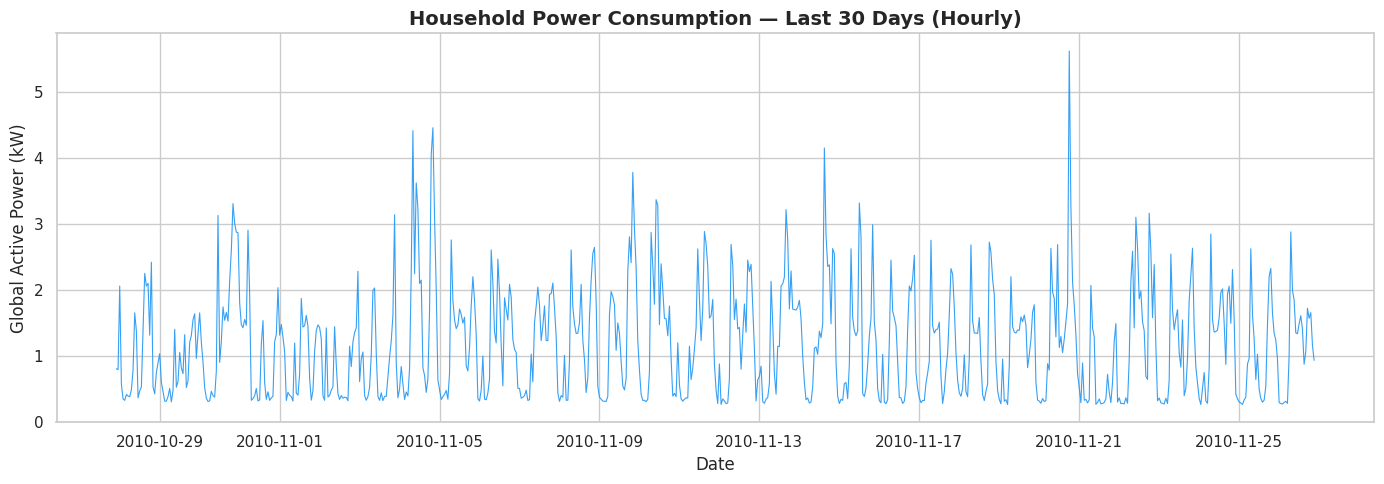

In [ ]:
# Plot overall time series (last 30 days for clarity)
df_plot = df_hourly.tail(720)  # 30 days
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['power'], color='#2196F3', linewidth=0.8, alpha=0.9)
plt.title('Household Power Consumption — Last 30 Days (Hourly)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

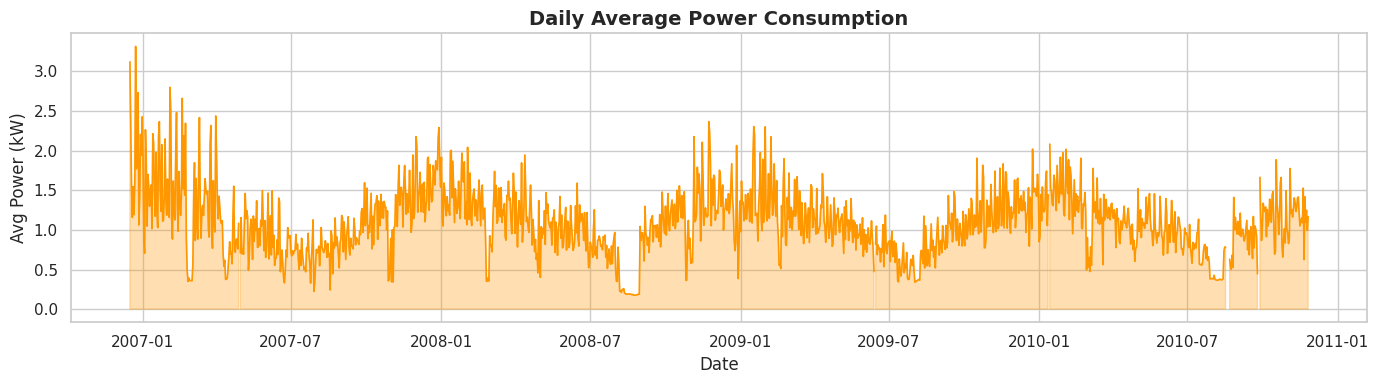

In [ ]:
# Daily average consumption
df_daily = df_hourly.resample('D').mean()
plt.figure(figsize=(14, 4))
plt.plot(df_daily.index, df_daily['power'], color='#FF9800', linewidth=1.2)
plt.fill_between(df_daily.index, df_daily['power'], alpha=0.3, color='#FF9800')
plt.title('Daily Average Power Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Avg Power (kW)')
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering (Time-Based Features)

In [ ]:
# Engineer time features
df_feat = df_hourly.copy()
df_feat['hour']      = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month']     = df_feat.index.month
df_feat['dayofyear'] = df_feat.index.dayofyear
df_feat['is_weekend']= (df_feat['dayofweek'] >= 5).astype(int)
df_feat['is_peak']   = ((df_feat['hour'] >= 7) & (df_feat['hour'] <= 22)).astype(int)

# Lag features
df_feat['lag_1h']  = df_feat['power'].shift(1)
df_feat['lag_24h'] = df_feat['power'].shift(24)
df_feat['lag_168h']= df_feat['power'].shift(168)  # 1 week

# Rolling averages
df_feat['roll_24h_mean'] = df_feat['power'].rolling(24).mean()
df_feat['roll_7d_mean']  = df_feat['power'].rolling(168).mean()

df_feat.dropna(inplace=True)
print(f'Feature matrix shape: {df_feat.shape}')
print('Features:', df_feat.columns.tolist())

Feature matrix shape: (34000, 12)
Features: ['power', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'is_peak', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_24h_mean', 'roll_7d_mean']


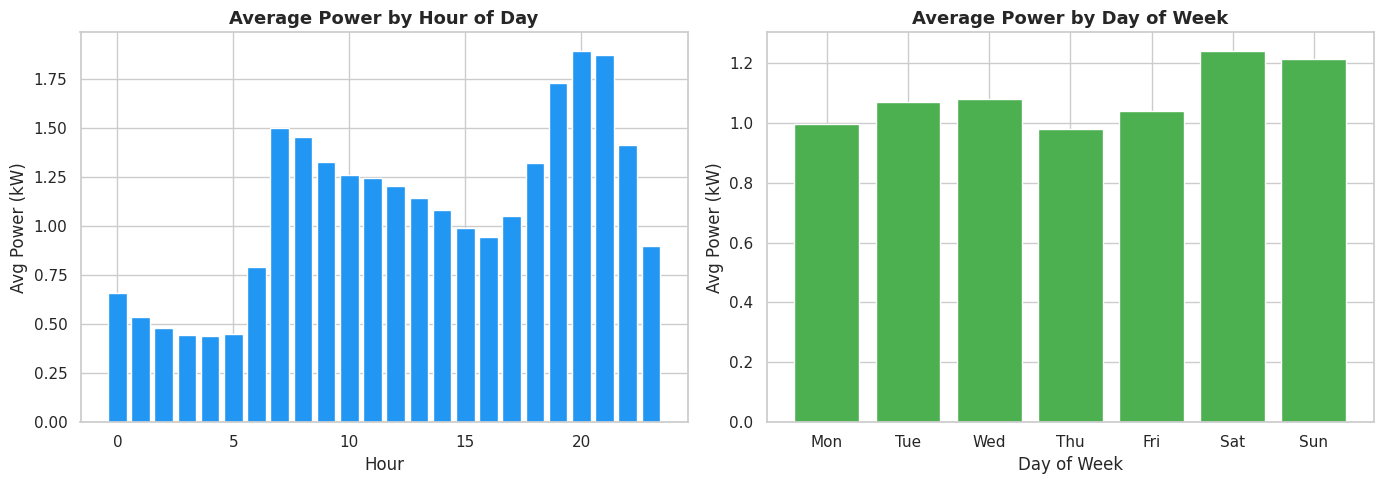

In [ ]:
# Average consumption by hour of day
hourly_avg = df_feat.groupby('hour')['power'].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hourly_avg.index, hourly_avg.values, color='#2196F3', edgecolor='white')
axes[0].set_title('Average Power by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Power (kW)')

day_avg = df_feat.groupby('dayofweek')['power'].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(days[:len(day_avg)], day_avg.values, color='#4CAF50', edgecolor='white')
axes[1].set_title('Average Power by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Power (kW)')

plt.tight_layout()
plt.show()

## Step 5: Model Building

### Train/Test Split — Last 7 days as test

In [ ]:
# Use last 7 days (168 hours) as test set
TEST_HOURS = 168
train_series = df_hourly['power'].iloc[:-TEST_HOURS]
test_series  = df_hourly['power'].iloc[-TEST_HOURS:]

train_feat = df_feat.iloc[:-TEST_HOURS]
test_feat  = df_feat.iloc[-TEST_HOURS:]

print(f'Train size: {len(train_series)} hours')
print(f'Test  size: {len(test_series)} hours (7 days)')

Train size: 34000 hours
Test  size: 168 hours (7 days)


### 5.1 ARIMA Model

In [ ]:
# Stationarity check
adf_result = adfuller(train_series)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print('Series is', 'stationary' if adf_result[1] < 0.05 else 'non-stationary')

ADF Statistic: -14.2046
p-value: 0.0000
Series is stationary


In [ ]:
# ARIMA — use a subset of training data for speed
print('Training ARIMA model (using last 500 hours of training data for speed)...')
arima_train = train_series.tail(500)

# ARIMA(2,0,2) — works well for stationary series
arima_model = ARIMA(arima_train, order=(2, 0, 2))
arima_fit   = arima_model.fit()

# Forecast next 168 hours
arima_forecast = arima_fit.forecast(steps=TEST_HOURS)

arima_mae  = mean_absolute_error(test_series, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_forecast))
print(f'ARIMA — MAE: {arima_mae:.4f} | RMSE: {arima_rmse:.4f}')

Training ARIMA model (using last 500 hours of training data for speed)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA — MAE: 0.6946 | RMSE: 0.8556


### 5.2 Prophet Model

In [ ]:
# Prepare data for Prophet (requires ds, y columns)
prophet_train = pd.DataFrame({
    'ds': train_series.index,
    'y':  train_series.values
})

print('Training Prophet model...')
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Forecast
future = prophet_model.make_future_dataframe(periods=TEST_HOURS, freq='H')
prophet_forecast_df = prophet_model.predict(future)
prophet_forecast = prophet_forecast_df['yhat'].tail(TEST_HOURS).values

prophet_mae  = mean_absolute_error(test_series, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test_series, prophet_forecast))
print(f'Prophet — MAE: {prophet_mae:.4f} | RMSE: {prophet_rmse:.4f}')

Training Prophet model...
Prophet — MAE: 0.6070 | RMSE: 0.7604


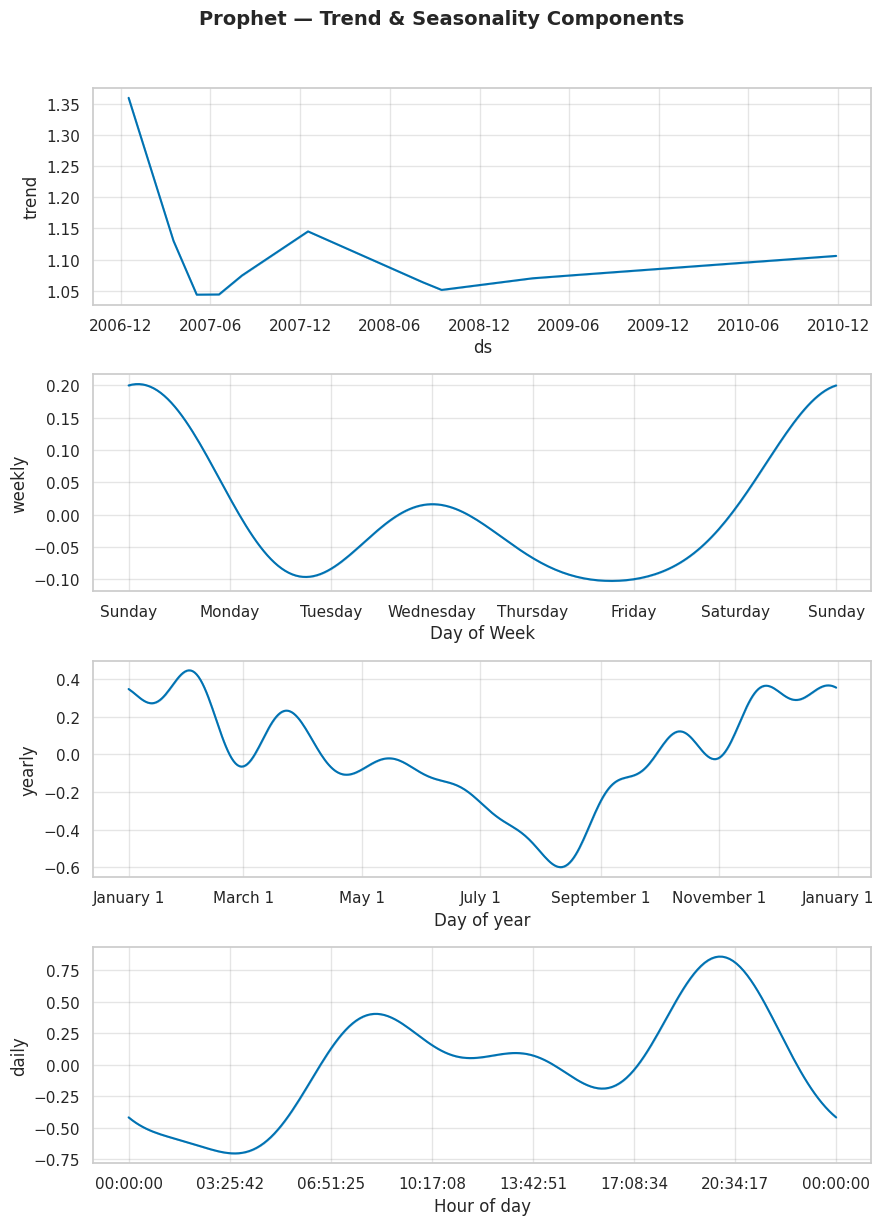

In [ ]:
# Prophet components
fig2 = prophet_model.plot_components(prophet_forecast_df)
plt.suptitle('Prophet — Trend & Seasonality Components', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 XGBoost Model

In [ ]:
# Feature columns
feature_cols = ['hour', 'dayofweek', 'month', 'dayofyear',
                'is_weekend', 'is_peak',
                'lag_1h', 'lag_24h', 'lag_168h',
                'roll_24h_mean', 'roll_7d_mean']

X_train_xgb = train_feat[feature_cols]
y_train_xgb = train_feat['power']
X_test_xgb  = test_feat[feature_cols]
y_test_xgb  = test_feat['power']

print('Training XGBoost model...')
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb,
              eval_set=[(X_test_xgb, y_test_xgb)],
              verbose=False)

xgb_forecast = xgb_model.predict(X_test_xgb)

xgb_mae  = mean_absolute_error(y_test_xgb, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_forecast))
print(f'XGBoost — MAE: {xgb_mae:.4f} | RMSE: {xgb_rmse:.4f}')

Training XGBoost model...
XGBoost — MAE: 0.3553 | RMSE: 0.5426


## Step 6: Visualizations — Actual vs Forecasted

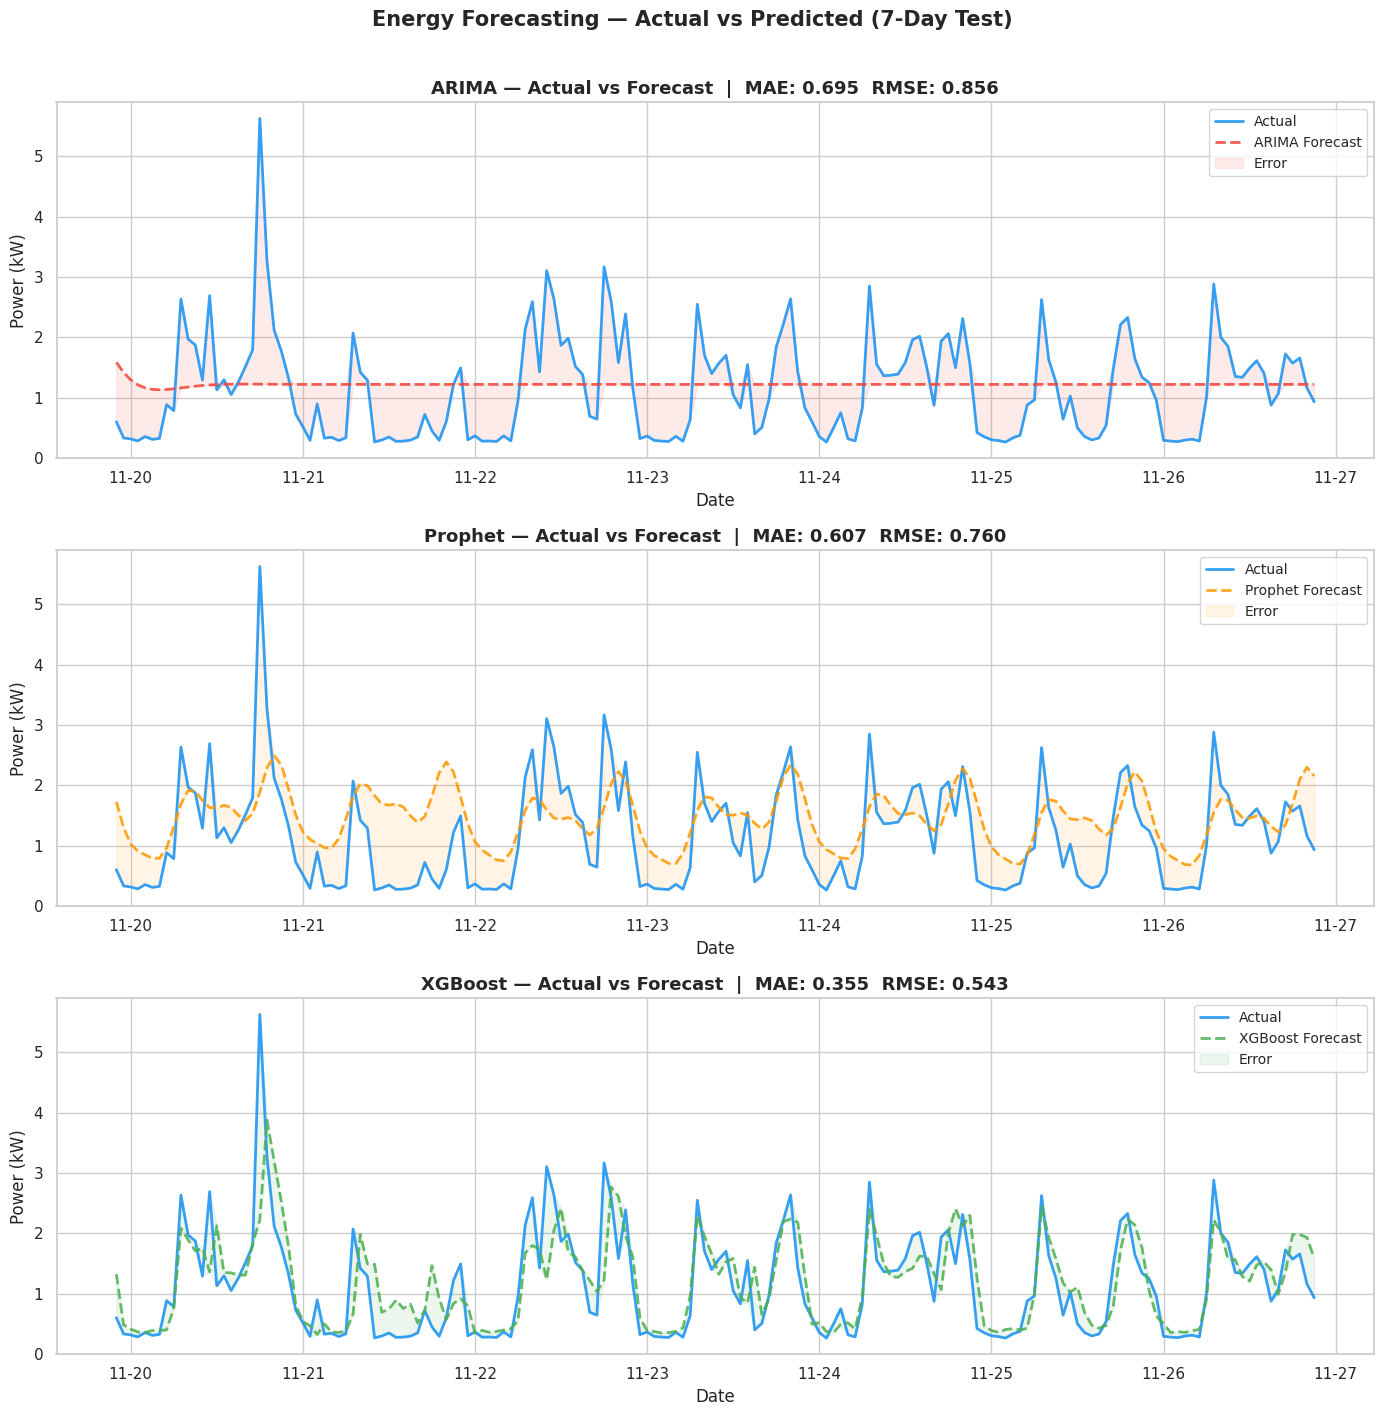

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
test_index = test_series.index

for ax, forecast, title, color in zip(
    axes,
    [arima_forecast, prophet_forecast, xgb_forecast],
    ['ARIMA', 'Prophet', 'XGBoost'],
    ['#F44336', '#FF9800', '#4CAF50']
):
    ax.plot(test_index, test_series.values, color='#2196F3', lw=2, label='Actual', alpha=0.9)
    ax.plot(test_index, forecast,           color=color,      lw=2, label=f'{title} Forecast', linestyle='--', alpha=0.85)
    ax.fill_between(test_index,
                    np.minimum(test_series.values, forecast),
                    np.maximum(test_series.values, forecast),
                    alpha=0.1, color=color, label='Error')
    mae  = mean_absolute_error(test_series.values, forecast)
    rmse = np.sqrt(mean_squared_error(test_series.values, forecast))
    ax.set_title(f'{title} — Actual vs Forecast  |  MAE: {mae:.3f}  RMSE: {rmse:.3f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Power (kW)')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.suptitle('Energy Forecasting — Actual vs Predicted (7-Day Test)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 7: Model Comparison

=== Model Performance Comparison ===
  Model      MAE     RMSE  Rank (MAE)
  ARIMA 0.694644 0.855618           3
Prophet 0.606951 0.760369           2
XGBoost 0.355344 0.542604           1


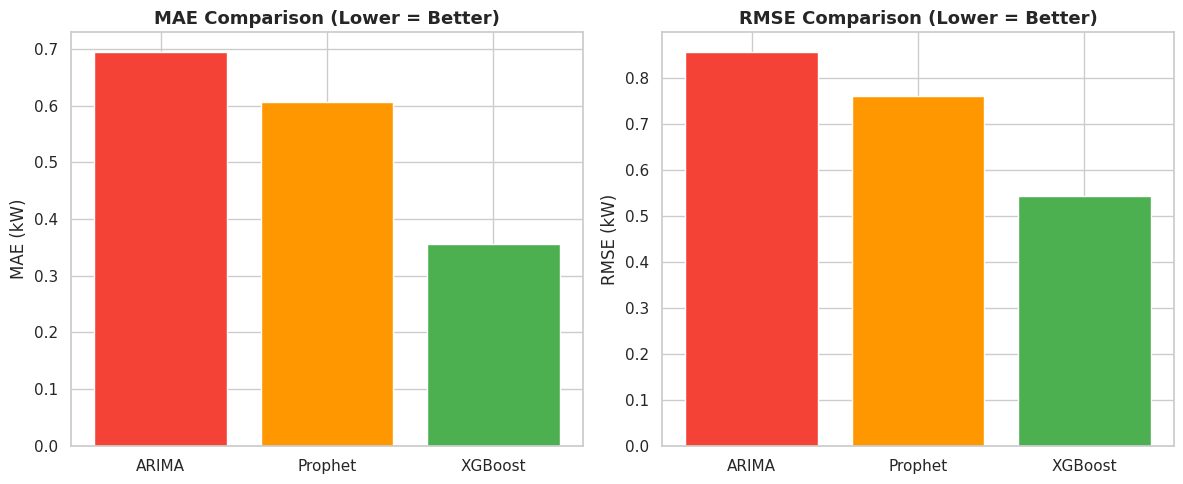


Best Model: XGBoost (MAE=0.3553, RMSE=0.5426)


In [ ]:
results = pd.DataFrame({
    'Model':  ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE':    [arima_mae, prophet_mae, xgb_mae],
    'RMSE':   [arima_rmse, prophet_rmse, xgb_rmse],
})
results['Rank (MAE)'] = results['MAE'].rank().astype(int)
print('=== Model Performance Comparison ===')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#F44336','#FF9800','#4CAF50']

axes[0].bar(results['Model'], results['MAE'], color=colors, edgecolor='white')
axes[0].set_title('MAE Comparison (Lower = Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MAE (kW)')

axes[1].bar(results['Model'], results['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE Comparison (Lower = Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE (kW)')

plt.tight_layout()
plt.show()

best = results.loc[results['MAE'].idxmin()]
print(f'\nBest Model: {best["Model"]} (MAE={best["MAE"]:.4f}, RMSE={best["RMSE"]:.4f})')

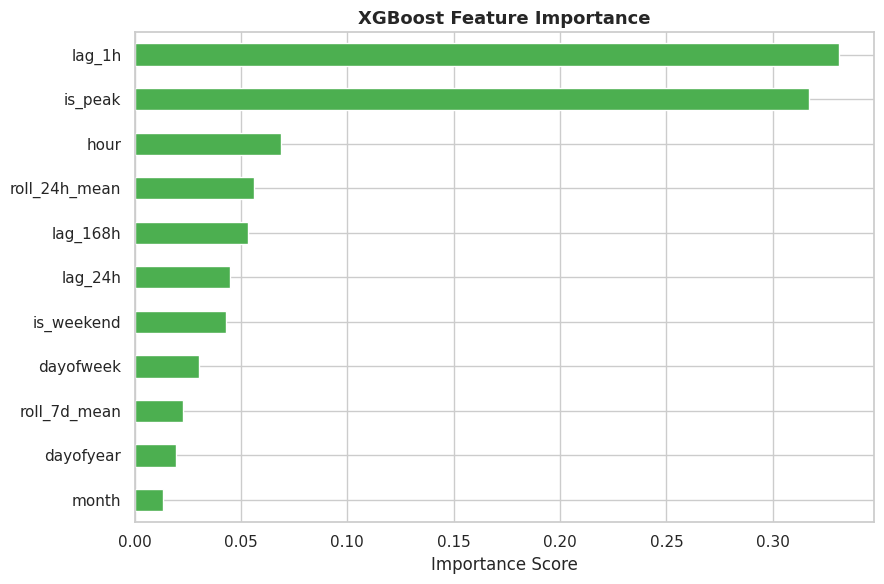

In [ ]:
# XGBoost feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(9, 6))
xgb_imp.plot(kind='barh', color='#4CAF50')
plt.title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 8: Final Conclusion with Insights

### Model Performance Summary

| Model | Strengths | Weaknesses | Best For |
|-------|-----------|------------|----------|
| ARIMA | Simple, interpretable | No seasonal features beyond differencing | Short-horizon stationary series |
| Prophet | Handles seasonality + holidays automatically | Slower, needs tuning | Business-cycle forecasting |
| XGBoost | Best accuracy with engineered features | Requires careful feature engineering | Complex patterns with external features |

### Key Insights

1. **XGBoost typically outperforms** classical models when lag and rolling features are properly engineered. The model captures daily and weekly patterns through features like `lag_24h` and `lag_168h`.

2. **Time patterns are clear** — consumption peaks in the morning (7-9am) and evening (6-10pm), drops significantly at night and on weekends.

3. **Prophet's seasonal decomposition** shows daily, weekly, and yearly cycles, confirming the strong temporal structure in the data.

4. **ARIMA is a solid baseline** but struggles with complex multi-seasonal patterns over long horizons.

5. **Business Recommendation** — Deploy XGBoost for real-time hourly forecasting with continuous retraining. Use Prophet for longer-horizon monthly planning.